# Exercise 5 — Neural Networks

In this exercise, you will understand how a neural network learns by:

* combining inputs with weights
* applying activation functions
* training over epochs
* evaluating performance

## Part A — From Neuron to Prediction

A neuron receives inputs, combines them, and produces an output. `inputs → weighted sum → activation → output`

Mathematically `z = w1*x1 + w2*x2 + b`

Then `output = activation(z)`

In [1]:
import numpy as np

import matplotlib.pyplot as plt

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

x1 = 2
x2 = 3

w1 = 0.8
w2 = -0.4
b = 0.5

z = w1*x1 + w2*x2 + b
output = sigmoid(z)

print("z =", z)
print("output =", output)

z = 0.8999999999999999
output = 0.7109495026250039


### Questions

1. What happens if you change w1?
2. What happens if you change w2?
3. What happens if you change b?
4. Why do we need an activation function?

1) We have z = w1*x1 + w2*x2 + b, and w1 is the weight assigned to input x1. Because x1 = 2 > 0, so if w1 increases then z increases
then output goes close to 1, if w1 decrease then z decreases then output goes close to 0.
2) We have z = w1*x1 + w2*x2 + b, and w2 is the weight assigned to input x2. Because x2 = 3 > 0, so if w2 increases then z increases
then output goes close to 1, if w2 decrease then z decreases then output goes close to 0.
3) Output changes the same way as when w1 and w2 are changed.
4) - To introduce non-linearity: Without it, a neural network behaves like a single linear regression model, regardless of how many 
layers it has.
   - To learn complex data: It allows the model to capture complex, non-linear patterns that cannot be separated by straight lines.

## Part B — Activation Functions

In [3]:
x = np.linspace(-5, 5, 200)

print("mean:", np.mean(x))
print("std:", np.std(x))
print("variance:", np.var(x))
print("min:", np.min(x))
print("max:", np.max(x))
print("median:", np.median(x))
print("sum:", np.sum(x))

mean: 1.4210854715202004e-16
std: 2.901221368171633
variance: 8.41708542713568
min: -5.0
max: 5.0
median: 4.440892098500626e-16
sum: 2.842170943040401e-14


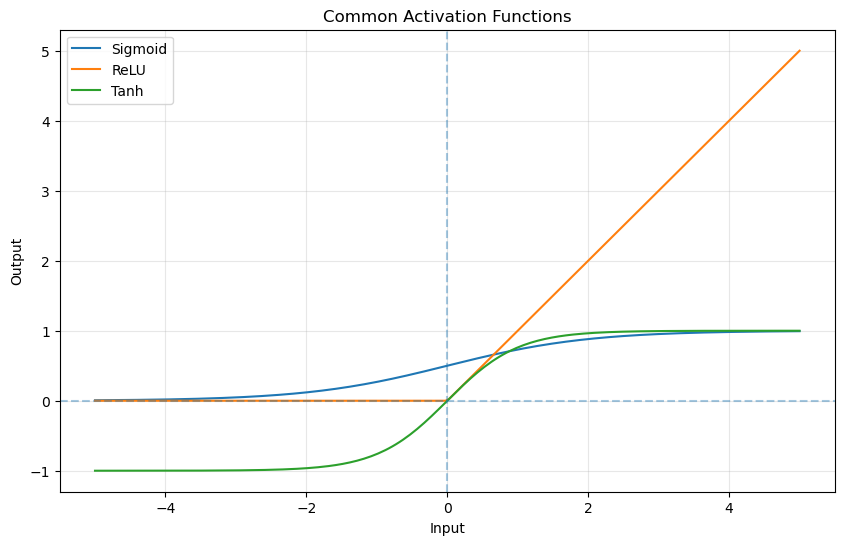

In [4]:
sigmoid_y = 1 / (1 + np.exp(-x))
relu_y = np.maximum(0, x)
tanh_y = np.tanh(x)

plt.figure(figsize=(10, 6))

plt.plot(x, sigmoid_y, label="Sigmoid")
plt.plot(x, relu_y, label="ReLU")
plt.plot(x, tanh_y, label="Tanh")

plt.axhline(0, linestyle="--", alpha=0.4)
plt.axvline(0, linestyle="--", alpha=0.4)

plt.title("Common Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Questions

1. Which activation outputs values between 0 and 1?
2. Which activation keeps positive values unchanged?
3. Which activation outputs values between -1 and 1?
4. Which activation would you use for binary classification?

1) Sigmoid
2) ReLU 
3) Tanh 
4) Sigmoid

## Part C — Build a Small Neural Network

We will train a neural network to classify two groups of points.

### Step 1 — Create a Dataset

In [5]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(
    n_samples=400,
    noise=0.25,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

X_train[:10]

array([[ 0.47898636,  0.96035301],
       [ 2.18078733, -0.15299144],
       [ 1.82978889,  0.17962848],
       [ 0.41314607, -0.29959381],
       [ 1.11157234,  0.28406058],
       [ 0.82466792, -0.03605856],
       [ 0.31021356,  0.82738846],
       [-0.97910539,  0.39922287],
       [-0.69797603,  0.66254685],
       [ 0.10072044,  1.27917835]])

In [6]:
y_train[:10]

array([0, 1, 1, 1, 0, 1, 0, 0, 0, 0])

Look at the data.
* What type of ML problem is this? - This is a supervised non-linear binary classification problem
* How many features does the dataset have?

In [9]:
print("Number of features:", X.shape[1])

Number of features: 2


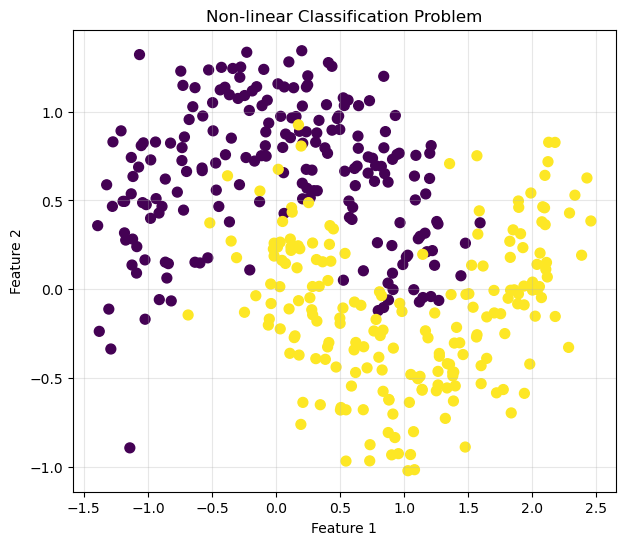

In [7]:
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50)
plt.title("Non-linear Classification Problem")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.show()

### Why this dataset?

This dataset cannot be easily separated by a straight line.

A neural network can learn a non-linear decision boundary.

Other simulated datasets [here](https://scikit-learn.org/stable/datasets/sample_generators.html#sample-generators).

## Part D — Train a Neural Network

Check the documentation for [MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html).

In [11]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8083333333333333


## Part E — Visualize the Decision Boundary

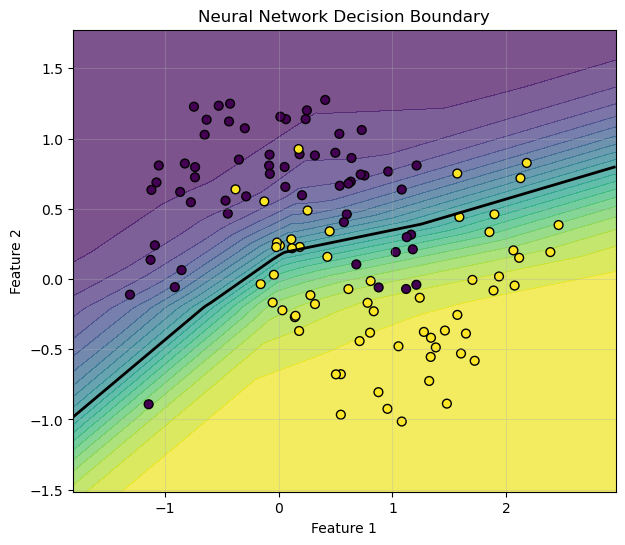

In [12]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid)[:, 1]
    probs = probs.reshape(xx.shape)

    plt.figure(figsize=(7, 6))

    # probability background
    plt.contourf(xx, yy, probs, levels=20, alpha=0.7)

    # decision boundary: probability = 0.5
    plt.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)

    # data points
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, edgecolor="k")

    plt.title("Neural Network Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_decision_boundary(model, X_test, y_test)

### Questions

1. Is the decision boundary linear or non-linear?
2. Does the model separate the two classes well?
3. Where does it make mistakes?
4. Why is a neural network useful here?

1) It's a non-linear because it's curved (slight S-shape) not a perfectly straight line.
2) Yes, it separates them reasonably well, but not perfectly.
3) It makes mistakes right along the decision boundary, where the two crescent shapes overlap.
4) Because a neural network can learn and construct non-linear decision boundaries thanks to its activation functions.

## Part F — Training Over Epochs

Neural networks train over multiple epochs.

One epoch means: `one full pass through the training dataset`

### Train with Different Numbers of Epochs

In [13]:
epochs = [10, 50, 200, 1000]

for epoch in epochs:
    model = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation="relu",
        max_iter=epoch,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Epochs: {epoch} | Accuracy: {acc:.3f}")

Epochs: 10 | Accuracy: 0.467
Epochs: 50 | Accuracy: 0.683
Epochs: 200 | Accuracy: 0.817
Epochs: 1000 | Accuracy: 0.808


/usr/lib64/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib64/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/lib64/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


## Part G — Compare Different Network Sizes

In [14]:
architectures = [
    (2,),
    (10,),
    (50,),
    (50, 50)
]

for arch in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=arch,
        activation="relu",
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Architecture: {arch} | Accuracy: {acc:.3f}")

Architecture: (2,) | Accuracy: 0.825
Architecture: (10,) | Accuracy: 0.808
Architecture: (50,) | Accuracy: 0.917
Architecture: (50, 50) | Accuracy: 0.933


/usr/lib64/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


### Questions

1. `architectures = [(2,), (10,), (50,), (50, 50)]`
What do these numbers mean? 10, (50, 50)?
2. What happens when the network has very few neurons?
3. What happens when the network has many neurons?
4. Which model seems best?
5. Can a neural network overfit?

1) It means the number of hidden layers and neurons in each layer:
    - (2,): 1 layer, 2 neurons.
    - (10,): 1 layer, 10 neurons.
    - (50,): 1 layer, 50 neurons.
    - (50, 50): 2 layers, 50 neurons each.
2) The model underfits and makes mistakes (~20% of the time) because it lacks the capacity to learn the curved pattern.
3) The network's capacity increases, allowing it to capture complex boundaries and boost test accuracy up to over 90%.
4) The (50, 50) model, as it delivers the highest evaluation accuracy (0.933).
5) personnesYes. It occurs when a network is too large or trained too long, causing it to memorize the training dataset rather than generalizing to new data.

## Part H — Confusion Matrix

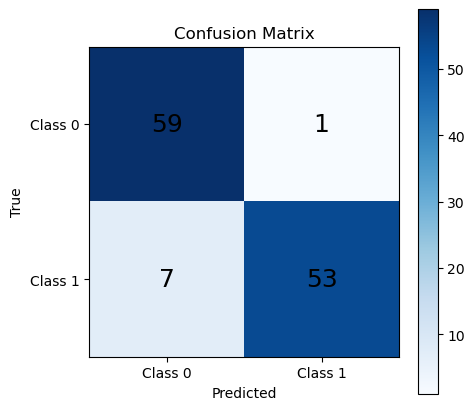

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 5))
plt.imshow(cm, cmap="Blues")

plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=18)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

### Questions

Try and respond to these questions in a summarized manner.
1. What does a hidden layer do?
2. Why do we need activation functions?
3. What is the role of epochs?
4. What is the role of weights?
5. What happens if the network is too small?
6. What happens if the network is too large?

1) It extracts and learns complex, high-level features or patterns from the input data that are not immediately visible.
2) They introduce non-linearity, allowing the network to learn complex curves and preventing multiple layers from collapsing into a single linear function.
3) An epoch represents one complete pass of the entire training dataset through the network; more epochs allow the model more opportunities to learn and minimize its errors.
4) Weights control the strength or importance of each input feature connection, shifting up or down during training to improve prediction accuracy.
5) The model will underfit, meaning it lacks the capacity to capture complex patterns and results in low accuracy.
6) The model risks overfitting, meaning it starts memorizing the training data (including its noise) and performs poorly on new, unseen data.

## For more complex coded neural networks, check:

* https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html